# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imágenes de ropa, como tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imágenes en 10 categorias. Las imágenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

In [3]:
dataset = keras.datasets.fashion_mnist
dataset.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [4]:
len(dataset.load_data()[0])

2

In [5]:
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset. Los guardamos en la siguiente lista:

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)

10

In [7]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [8]:
print(X_train.shape) # 60000 imágenes en train
print(X_test.shape) # 1000 imágenes en test

print(X_train.shape[1:],X_train.shape[1] * X_train.shape[2]) # 28 x 28 dimensiones de cada imagen (784 pixels)

print(np.unique(y_train)) # labels posibles
print(len(class_names)) # num clases

(60000, 28, 28)
(10000, 28, 28)
(28, 28) 784
[0 1 2 3 4 5 6 7 8 9]
10


## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

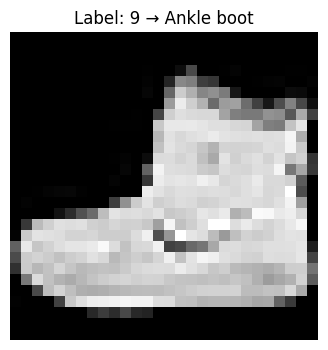

In [9]:
plt.figure(figsize=(4,4))
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]} → {class_names[y_train[0]]}")
plt.axis('off')


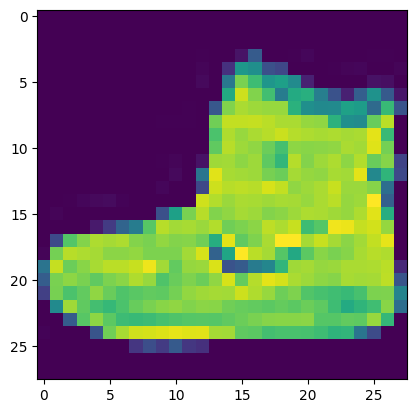

In [12]:
plt.imshow(X_train[0]);

C:\Users\titea\AppData\Local\Temp\ipykernel_31556\2801916547.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_train[0], cmap=plt.cm.get_cmap('Greys'));


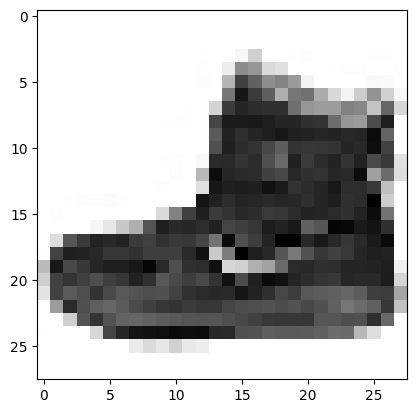

In [11]:
plt.imshow(X_train[0], cmap=plt.cm.get_cmap('Greys'));

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [15]:
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

X_train_scaled.min(), X_train_scaled.max(), X_test_scaled.min(), X_test_scaled.max()


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

In [16]:
# Reservar 10.000 imágenes para validación
X_val = X_train_scaled[-10000:]
y_val = y_train[-10000:]

# Mantener el resto como training
X_train_final = X_train_scaled[:-10000]
y_train_final = y_train[:-10000]

print("Train:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_scaled.shape)


Train: (50000, 28, 28)
Validation: (10000, 28, 28)
Test: (10000, 28, 28)


Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

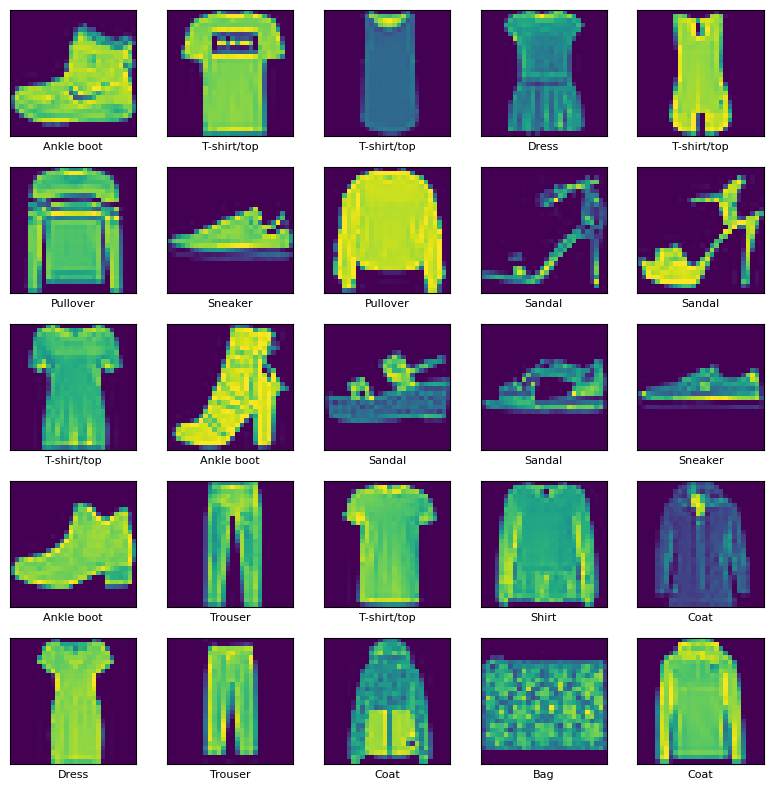

In [42]:
plt.figure(figsize=(8,8))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train_scaled[i])
    plt.xlabel(class_names[y_train[i]], fontsize=8)
    #plt.axis('off')

plt.tight_layout()
plt.show()


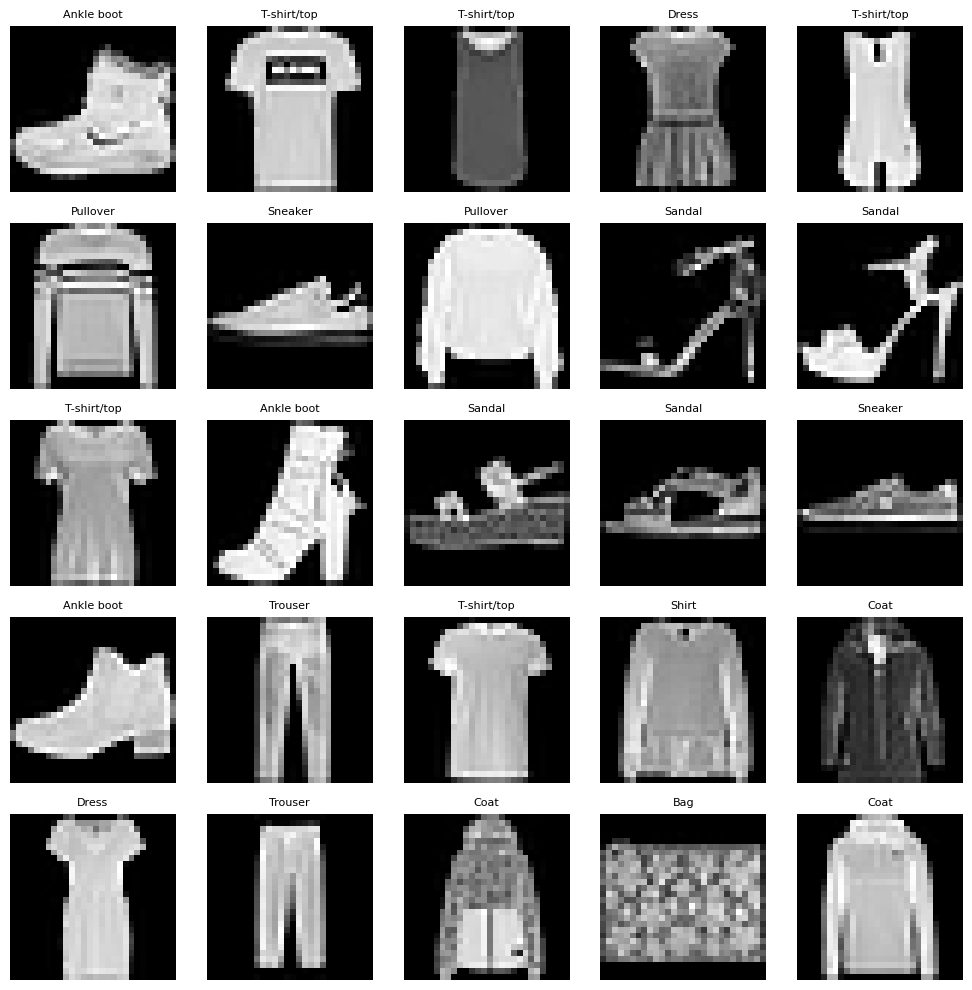

In [36]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_scaled[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [18]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)), # aplana la imagen 28x28 → vector de 784
    layers.Dense(128, activation='relu'), # capa oculta con 128 neuronas
    layers.Dense(10, activation='softmax')]) # capa de salida con 10 clases


model.summary()

c:\Users\titea\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [19]:
model.compile(
    optimizer = keras.optimizers.SGD(),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

In [20]:
# modo abreviado:
'''
model.compile(
    optimizer = "sgd",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
'''

'\nmodel.compile(\n    optimizer = "sgd",\n    loss = "sparse_categorical_crossentropy",\n    metrics = ["accuracy"]\n)\n'

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [ ]:

history = model.fit(
    X_train_final,
    y_train_final,
    batch_size = 128,
    epochs = 50,
    validation_data = (X_val, y_val))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1404 - sparse_categorical_accuracy: 0.6608 - val_loss: 0.7926 - val_sparse_categorical_accuracy: 0.7405
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7168 - sparse_categorical_accuracy: 0.7657 - val_loss: 0.6641 - val_sparse_categorical_accuracy: 0.7776
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6247 - sparse_categorical_accuracy: 0.7961 - val_loss: 0.5995 - val_sparse_categorical_accuracy: 0.7994
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5756 - sparse_categorical_accuracy: 0.8113 - val_loss: 0.5635 - val_sparse_categorical_accuracy: 0.8113
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5438 - sparse_categorical_accuracy: 0.8203 - val_loss: 0.5463 - val_sparse_categorical_accuracy: 0.8132
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5208 - sparse_categorical_accuracy: 0.8264 - val_loss: 0.5194 - val_sparse_categorical_accuracy: 0.8228
Epoc

In [22]:
# Escalar → Separar validation → Configurar modelo → Compilar → Entrenar

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [43]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=1)

print(test_loss)
print(test_acc)


# accuracy del 85.6%, significa que el modelo clasifica correctamente 8.56 de cada 10
# imágenes nuevas que nunca ha visto.

# test loss 0.404, indica que modelo generaliza razonablemente bien, no hay señales de sobreajuste extremo.

# la validación y el test deberían estar en rangos similares.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.4031 - sparse_categorical_accuracy: 0.8562
0.4031064808368683
0.8561999797821045


## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

In [24]:
predictions = model.predict(X_test_scaled)
# cada predictions[i] es un vector de 10 probabilidades

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step


El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [25]:
predictions[0]

array([9.2982364e-06, 1.8018540e-06, 1.6450575e-05, 9.2845021e-06,
       4.9100186e-06, 8.7259836e-02, 3.4475288e-05, 8.8539608e-02,
       1.6654673e-03, 8.2245892e-01], dtype=float32)

In [26]:
pred_0 = np.argmax(predictions[0])
pred_0

np.int64(9)

In [27]:
class_names[pred_0]

'Ankle boot'

In [28]:
print("Predicción:", class_names[pred_0])
print("Etiqueta real:", class_names[y_test[0]])

Predicción: Ankle boot
Etiqueta real: Ankle boot


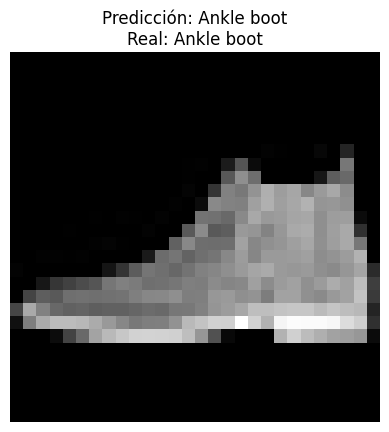

In [29]:
plt.imshow(X_test_scaled[0], cmap='gray')
plt.title(f"Predicción: {class_names[pred_0]}\nReal: {class_names[y_test[0]]}")
plt.axis('off')
plt.show()

*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [30]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step


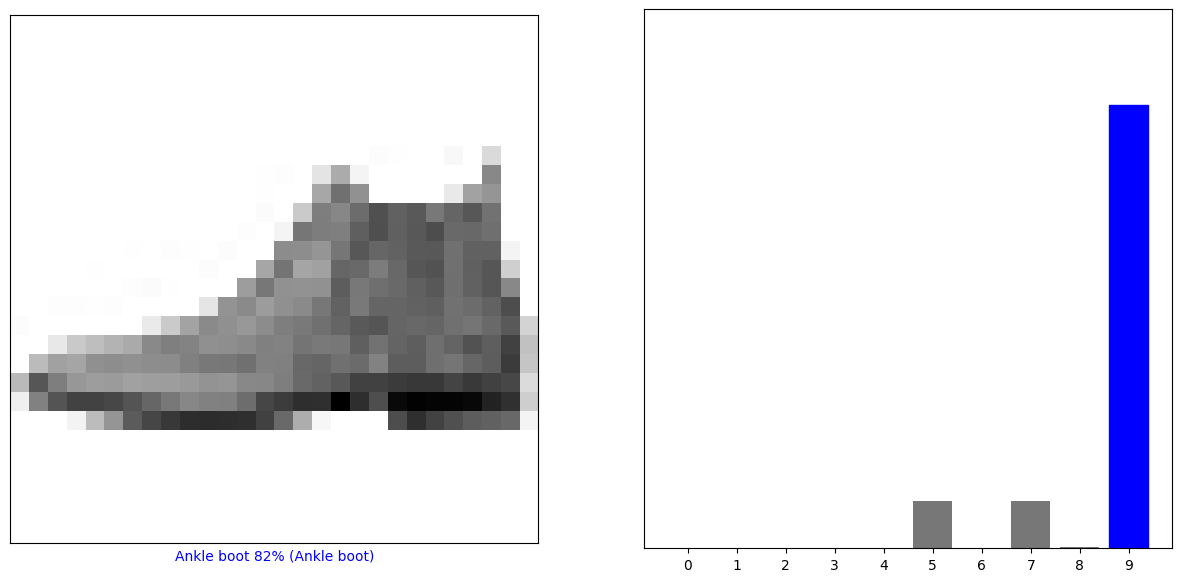

In [31]:
# obtener predicciones
y_pred = model.predict(X_test_scaled)

# visualizar la primera predicción
i = 0
plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plot_image(i, y_pred[i], y_test, X_test_scaled)

plt.subplot(1,2,2)
plot_value_array(i, y_pred[i], y_test)

plt.show()


Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

Evalúa tu modelo con una matriz de confusión e interprétala.

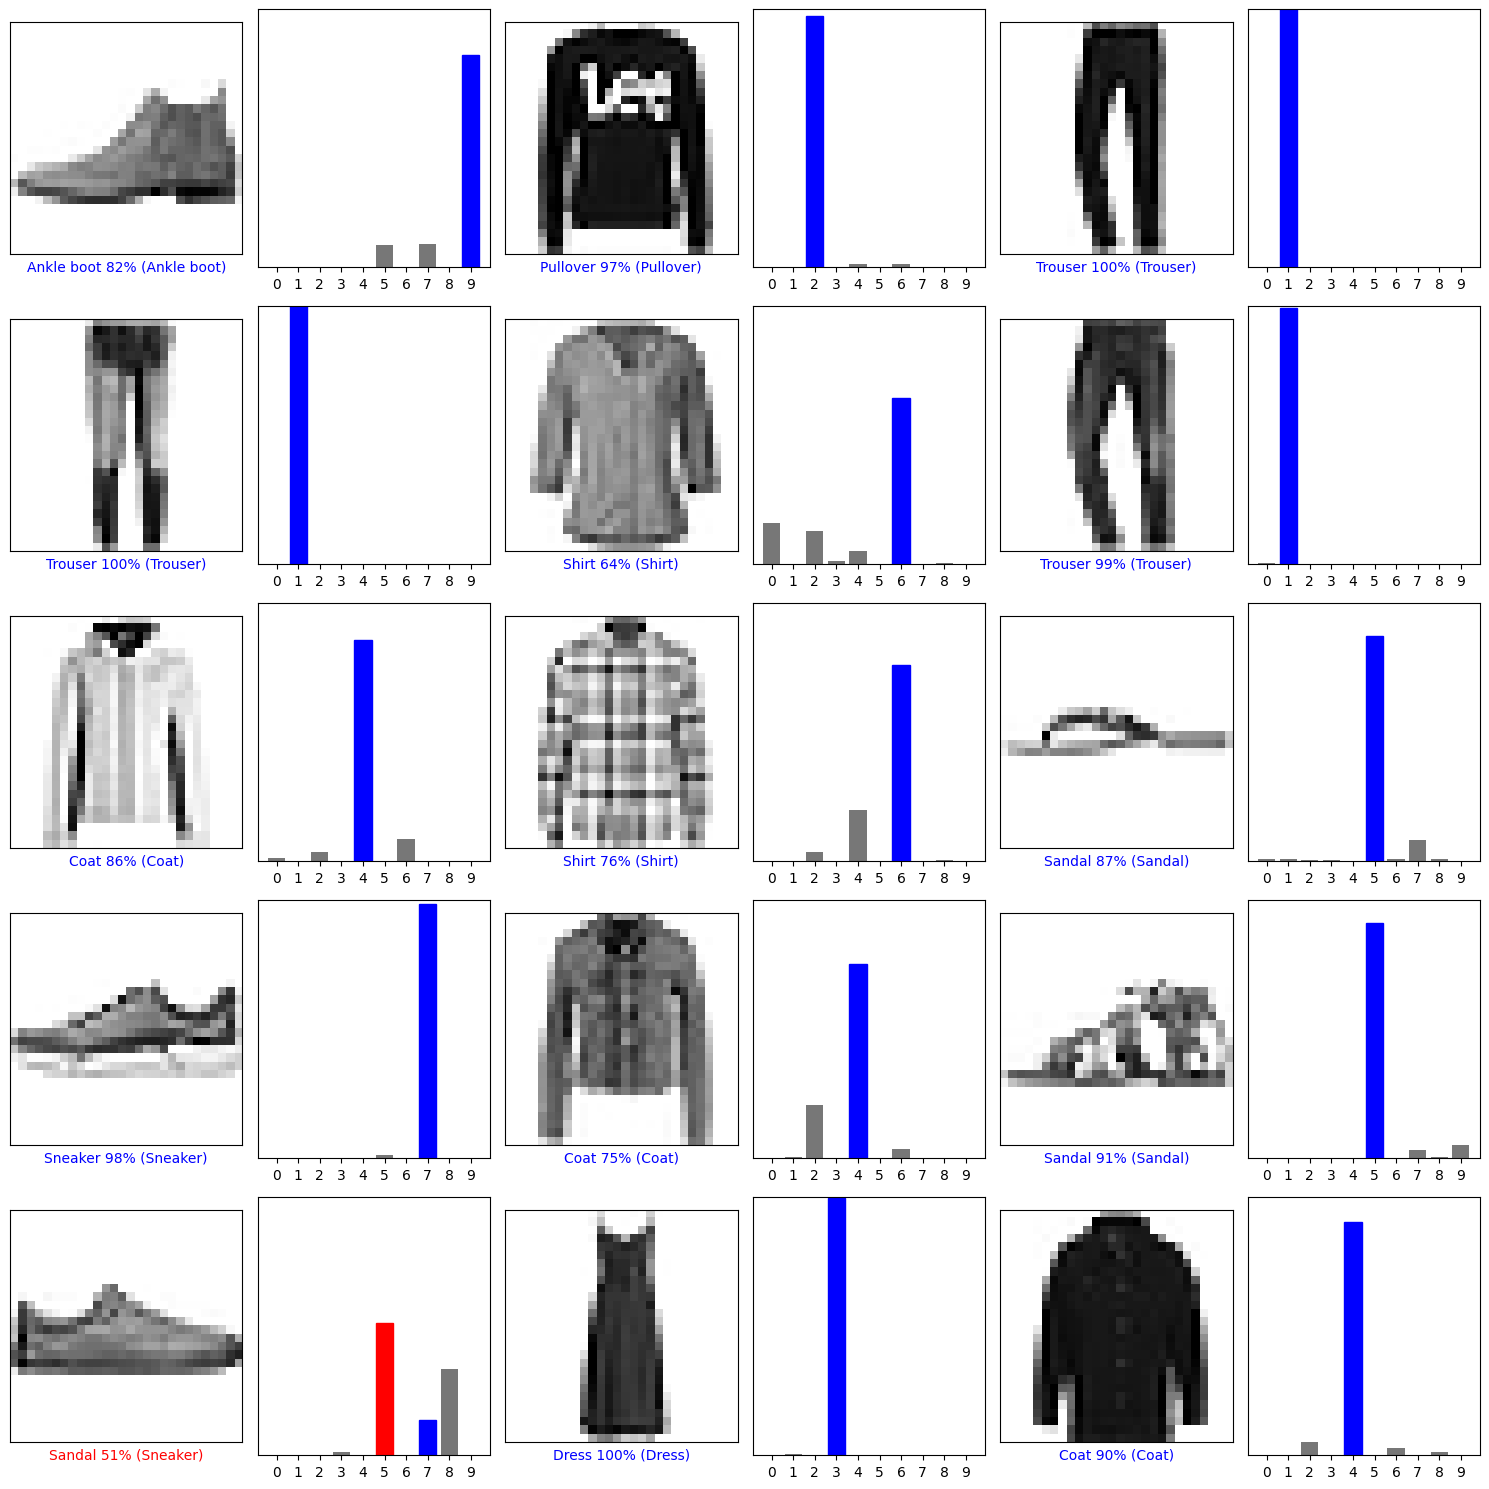

In [32]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(15, 15))

for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, y_pred[i], y_test, X_test_scaled)
    
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, y_pred[i], y_test)

plt.tight_layout()
plt.show()


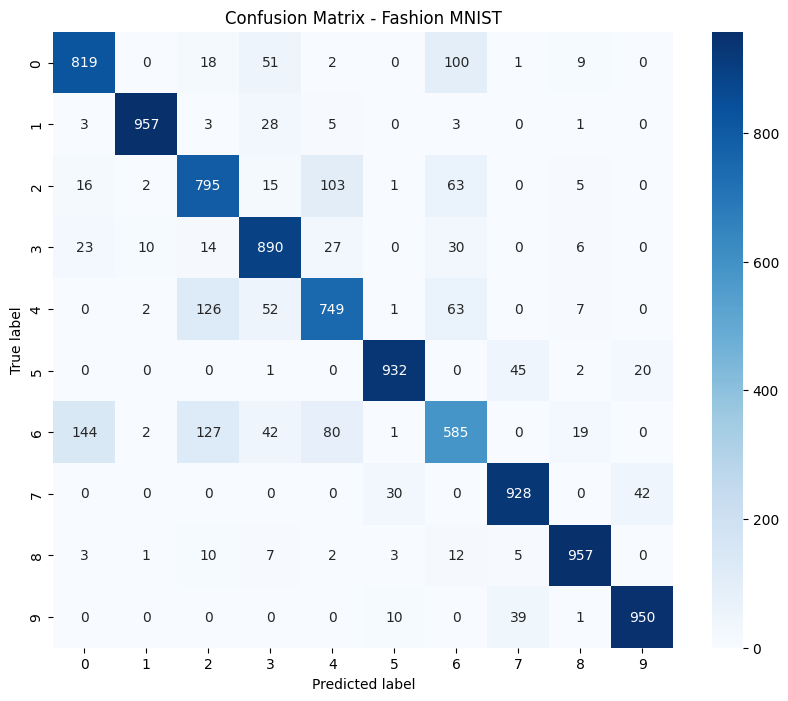

In [33]:
y_pred_labels = np.argmax(y_pred, axis=1)

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Fashion MNIST")
plt.show()


In [34]:
# Interpretación de la matriz de confusión

# La matriz de confusión nos permite analizar en detalle qué clases el modelo
# clasifica correctamente (diagonal) y cuáles confunde entre sí (fuera de la diagonal).
#
# Observaciones principales:
#
# 1) Clases fáciles (alta precisión):
#    - 'Trouser' (1) y 'Bag' (8) muestran valores muy altos en la diagonal
#      y muy pocos errores. Son prendas con siluetas muy distintivas, por lo que
#      el modelo las reconoce con facilidad.
#
# 2) Confusiones típicas entre prendas similares:
#    - 'T-shirt/top' (0) vs 'Shirt' (6):
#         * 0 → 6: 108 errores
#         * 6 → 0: 145 errores
#      Estas dos clases tienen formas muy parecidas en 28x28 píxeles, por lo que
#      una red densa (sin convoluciones) no distingue bien detalles como cuello o mangas.
#
#    - 'Pullover' (2) vs 'Coat' (4):
#         * 2 → 4: 114 errores
#         * 4 → 2: 96 errores
#      Ambas prendas tienen contornos similares y el modelo tiende a confundirlas.
#
# 3) Calzado: 'Sneaker' (7) vs 'Ankle boot' (9):
#      * 7 → 9: 44 errores
#      * 9 → 7: 38 errores
#    Aunque son clases distintas, sus siluetas en escala de grises pueden ser parecidas.
#
# 4) Conclusión general:
#    - El modelo funciona bien en clases con formas muy distintivas.
#    - Las confusiones se concentran en prendas con siluetas similares.
#    - Esto es esperable en una red densa simple. Una CNN capturaría mejor
#      patrones locales y reduciría estas confusiones.
#
# En conjunto, la matriz confirma que el modelo generaliza razonablemente bien,
# pero tiene dificultades en clases visualmente parecidas, lo cual es coherente
# con la arquitectura utilizada.


Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicción del modelo: Ankle boot
Etiqueta real: Ankle boot


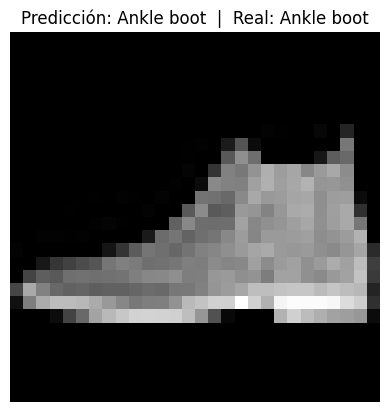

In [35]:
# Predicción sobre una única imagen del set de test

# Tomamos la imagen X_test_scaled[0] y la pasamos al modelo.
# IMPORTANTE: el modelo espera un batch (dimensión extra),
# por lo que usamos np.expand_dims para convertir (28,28)
# en (1,28,28).

img = X_test_scaled[0]

# Expandimos dimensiones para que el modelo lo interprete como un batch
img_batch = np.expand_dims(img, axis=0)

# Hacemos la predicción
pred_single = model.predict(img_batch)

# pred_single es un array de shape (1,10) → probabilidades para cada clase
# Obtenemos la clase predicha
pred_label = np.argmax(pred_single[0])

print("Predicción del modelo:", class_names[pred_label])
print("Etiqueta real:", class_names[y_test[0]])

# Visualizamos la imagen
plt.imshow(img, cmap='gray')
plt.title(f"Predicción: {class_names[pred_label]}  |  Real: {class_names[y_test[0]]}")
plt.axis('off')
plt.show()

# Comentario:
# El modelo devuelve un vector de 10 probabilidades.
# np.argmax selecciona la clase con mayor probabilidad.
# Esto reproduce exactamente el comportamiento descrito en la teoría:
# "Finalmente, usamos el modelo entrenado para hacer una predicción
#  sobre una única imagen."
